In [ ]:
#!conda install py3dep --yes

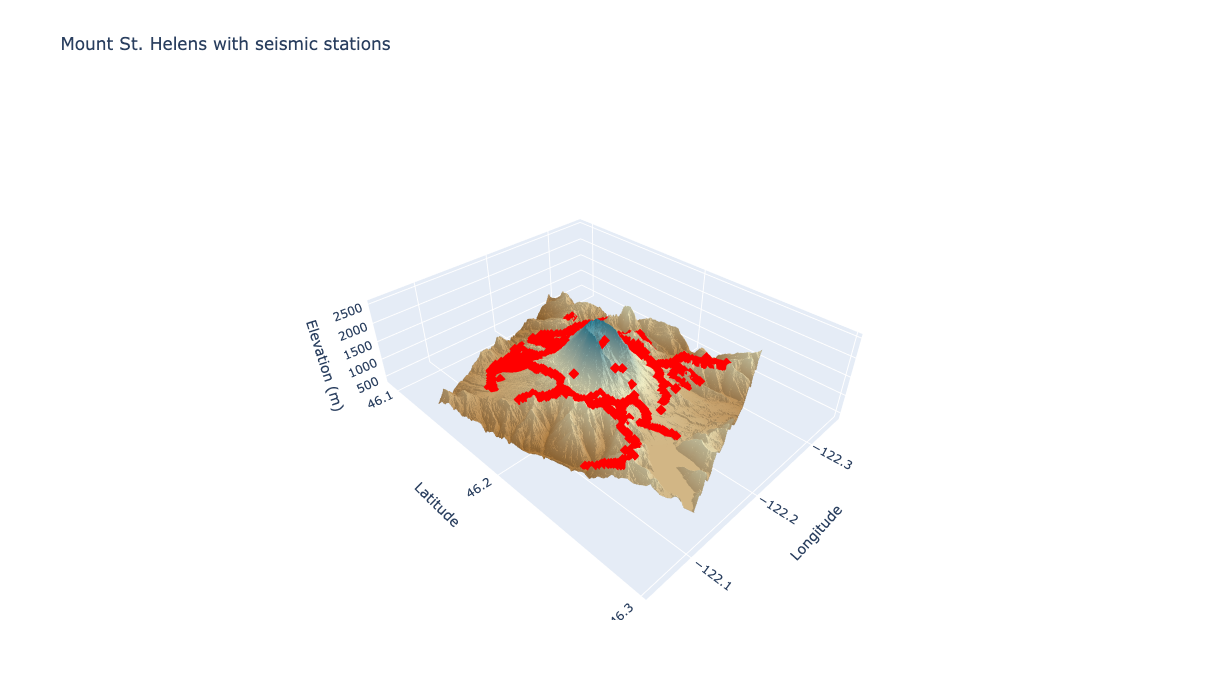

In [1]:
# 3D model of Mount St. Helens with seismic stations overlaid.
# Run in JupyterLab. Install dependencies first if needed:
#   %pip install py3dep plotly obspy

import numpy as np
import xarray as xr
import py3dep
import plotly.graph_objects as go
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

# --- Area of interest: (west, south, east, north) ---
bbox = (-122.30, 46.13, -122.10, 46.26)

# --- Elevation model from USGS 3DEP ---
dem = py3dep.get_dem(bbox, resolution=30)  # xarray DataArray, elevation in meters
dem = dem.rio.reproject(4326)

# --- Station metadata from EarthScope FDSN ---
client = Client("EARTHSCOPE")
inv = client.get_stations(
    minlongitude=bbox[0], minlatitude=bbox[1],
    maxlongitude=bbox[2], maxlatitude=bbox[3],
    startbefore=UTCDateTime("2017-01-01"),  # started before the end of 2016
    endafter=UTCDateTime("2014-01-01"),     # still running after the start of 2014
    level="station",
)

# Convert ObsPy Longitude/Latitude objects to plain floats for Plotly
lons = np.array([float(s.longitude) for n in inv for s in n])
lats = np.array([float(s.latitude) for n in inv for s in n])
names = [f"{n.code}.{s.code}" for n in inv for s in n]

# Sample the DEM at each station so markers sit on the terrain (+50 m offset)
z = dem.interp(
    x=xr.DataArray(lons, dims="pts"),
    y=xr.DataArray(lats, dims="pts"),
).values + 50

# --- Build the figure ---
fig = go.Figure(go.Surface(
    z=dem.values, x=dem.x, y=dem.y,
    colorscale="earth", showscale=False, name="Terrain",
))

fig.add_trace(go.Scatter3d(
    x=lons, y=lats, z=z,
    mode="markers",
    hovertext=names,
    hovertemplate="<b>%{hovertext}</b><br>Lat: %{y:.4f}<br>Lon: %{x:.4f}<br>Elev: %{z:.0f} m<extra></extra>",
    marker=dict(size=5, color="red", symbol="diamond"),
    name="Mt Saint Helens IMUSH Seismic stations",
))

fig.update_layout(
    title="Mount St. Helens with seismic stations",
    width=900, height=700,
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Elevation (m)",
        aspectmode="manual",
        aspectratio=dict(x=1, y=1.3, z=0.35),
    ),
)

fig.show()